## 多层感知机
### Fashion-MNIST 数据集里每一张图是：

### 格式：PIL 图像（或 numpy 数组）
### 大小：28 像素高 × 28 像素宽
### 颜色：灰度（只有一个通道，不是 RGB 彩色）
### 像素值：0 到 255 的整数（0=黑色，255=白色）


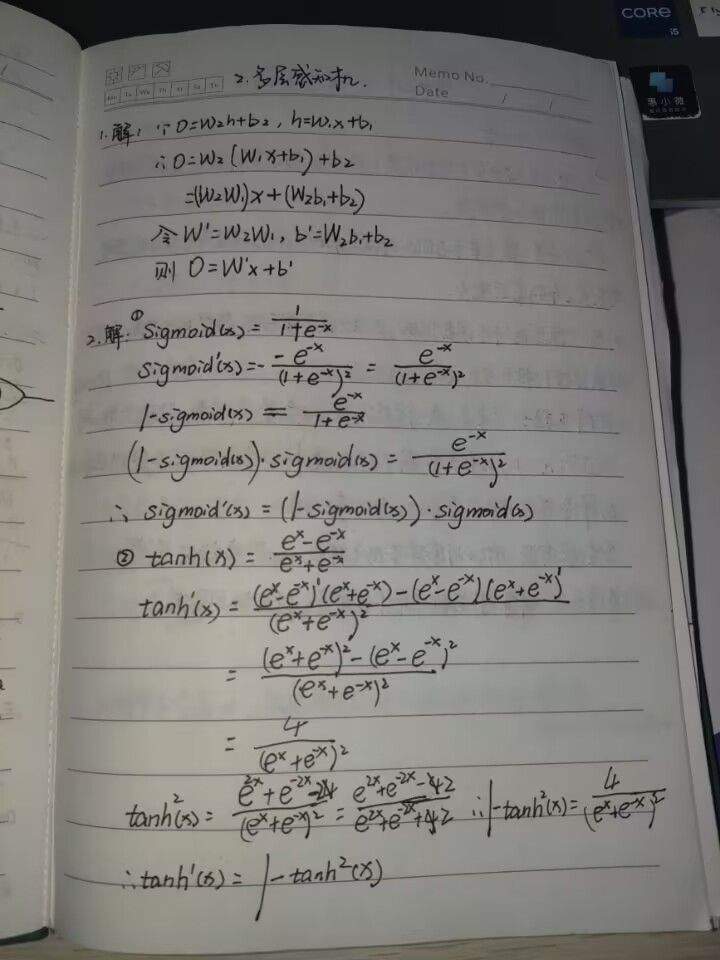

In [1]:

import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np


# -------------------- 1. 加载 Fashion-MNIST 数据集 --------------------
# x.view(-1)：x 是上一步输出的形状为 (1,28,28) 的张量;view(-1) 表示“自动把所有元素展平成一维”
transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])  # 展平为28*28=784
train_set=torchvision.datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)#训练集
test_set=torchvision.datasets.FashionMNIST(root='./data',train=False,download=True,transform=transform)#测试集

batch_size=64 #每次训练使用 64 张图片
train_loader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True)
test_loader =torch.utils.data.DataLoader(test_set,batch_size=batch_size,shuffle=False)


# -------------------- 2. 参数初始化 --------------------
input_size=784 #784个输入特征
hidden_size=256 #隐藏层神经元数量
output_size=10 #10个类别

# 正态分布初始化，标准差 0.01 有助于稳定训练
# 每个隐藏神经元都有自己专属的784个权重（随机数），与输入特征做点积后再加上自己的偏置
W1=torch.randn(784,256)*0.01
b1=torch.zeros(256)
W2=torch.randn(256,10)*0.01
b2=torch.zeros(10)
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)


# -------------------- 3. 定义前向传播函数 --------------------
def relu(x):
    return torch.maximum(x, torch.zeros_like(x))

def softmax(x):
    exp_x=torch.exp(x-torch.max(x,dim=1,keepdim=True)[0])
    return exp_x/torch.sum(exp_x,dim=1, keepdim=True)

# 交叉熵损失函数，输入是模型输出的 logits 和真实标签
def cross_entropy_loss(logits, labels):
    # logits: (batch, 10)  未经过 softmax
    # labels: (batch,)  类别索引 0~9
    probs=softmax(logits)
    # 交叉熵=-log(probs[样本, 真实类])
    batch_size=logits.shape[0]
    loss=-torch.log(probs[torch.arange(batch_size),labels]+1e-8)  # 加小量防止 log(0)
    return loss.mean()

# 前向传播函数，输入是 (batch, 784) 的图像张量，输出是 (batch, 10) 的 logits
def model_forward(x):
    # x: (batch, 784)
    h=x@W1+b1   # 线性变换
    h=relu(h)                    # ReLU 激活
    out=h@W2+b2 # 输出层 logits
    return out




# -------------------- 4. 训练循环 --------------------
learning_rate=0.1
num_epochs=10

for epoch in range(num_epochs):
    total_loss = 0.0
    for images, labels in train_loader:
        logits = model_forward(images)
        loss = cross_entropy_loss(logits, labels)
        loss.backward()
        with torch.no_grad():
            W1.sub_(learning_rate * W1.grad)
            b1.sub_(learning_rate * b1.grad)
            W2.sub_(learning_rate * W2.grad)
            b2.sub_(learning_rate * b2.grad)
            # 梯度清零
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    # 测试
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            logits = model_forward(images)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1:2d}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

print("训练完成。")



Epoch  1, Loss: 0.6826, Test Acc: 0.8180
Epoch  2, Loss: 0.4443, Test Acc: 0.8248
Epoch  3, Loss: 0.3988, Test Acc: 0.8387
Epoch  4, Loss: 0.3704, Test Acc: 0.8584
Epoch  5, Loss: 0.3509, Test Acc: 0.8633
Epoch  6, Loss: 0.3357, Test Acc: 0.8577
Epoch  7, Loss: 0.3228, Test Acc: 0.8586
Epoch  8, Loss: 0.3110, Test Acc: 0.8721
Epoch  9, Loss: 0.3008, Test Acc: 0.8619
Epoch 10, Loss: 0.2911, Test Acc: 0.8491
训练完成。


## 3.模型选择，权重衰减和丢弃法

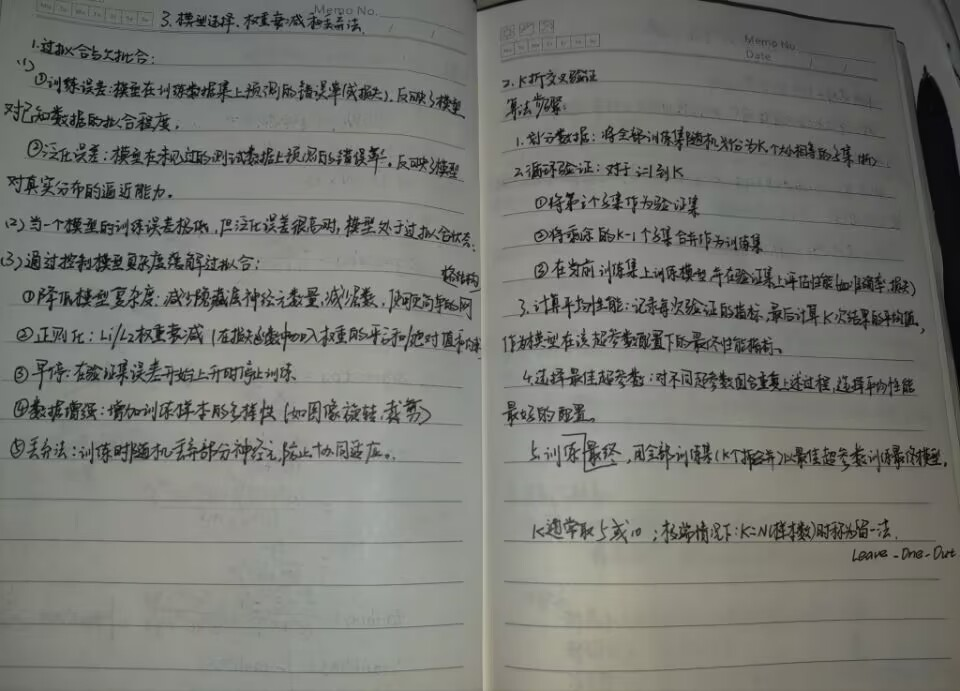

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子，使结果可复现（可选）
torch.manual_seed(42)


In [3]:
#加载数据集（只取 500 张训练样本，造成过拟合）
# # 图像预处理：转张量 + 展平为 784 维
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

# 完整训练集（60000张）和测试集（10000张）
full_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# 故意只取前 500 张作为训练集，加剧过拟合
train_set = torch.utils.data.Subset(full_train, list(range(500)))

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f"训练集样本数: {len(train_set)}")
print(f"测试集样本数: {len(test_set)}")

训练集样本数: 500
测试集样本数: 10000


In [4]:
#参数初始化（高容量模型，隐藏层 1024)
input_size = 784
hidden_size = 1024   # 大容量，容易过拟合
output_size = 10

# 注意：先创建普通张量，再开启 requires_grad，保证叶子节点
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

print("参数形状：")
print(f"W1: {W1.shape}, b1: {b1.shape}")
print(f"W2: {W2.shape}, b2: {b2.shape}")

参数形状：
W1: torch.Size([784, 1024]), b1: torch.Size([1024])
W2: torch.Size([1024, 10]), b2: torch.Size([10])


In [5]:
#定义基础组件（ReLU, Softmax, 交叉熵损失, Dropout）
def relu(x):
    """ReLU 激活函数"""
    return torch.maximum(x, torch.zeros_like(x))

def softmax(x):
    """数值稳定的 Softmax"""
    max_vals = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_vals)
    return exp_x / exp_x.sum(dim=1, keepdim=True)

def cross_entropy_loss(logits, labels):
    """交叉熵损失（包含 softmax）"""
    probs = softmax(logits)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[torch.arange(batch_size), labels] + 1e-8)
    return loss.mean()

def dropout_layer(X, dropout, is_training):
    """
    从零实现 Dropout
    X: 输入张量
    dropout: 丢弃概率
    is_training: 训练模式为 True，测试/验证为 False
    """
    if not is_training or dropout == 0.0:
        return X
    mask = torch.rand_like(X) > dropout   # 保留掩码
    return X * mask / (1.0 - dropout)     # 缩放保持期望不变

In [6]:
# 前向传播函数，包含 Dropout
def model_forward(x, dropout, is_training):
    """
    前向传播
    x: (batch, 784)
    dropout: 隐藏层后的 Dropout 概率
    is_training: 是否为训练阶段
    """
    h = x @ W1 + b1
    h = relu(h)
    h = dropout_layer(h, dropout, is_training)   # 参数名改为 dropout
    out = h @ W2 + b2
    return out

In [7]:
# 训练函数，包含权重衰减和 Dropout
def train_model(weight_decay, dropout, num_epochs=50, lr=0.1):
    """
    训练模型并记录损失和准确率
    weight_decay: L2 正则化系数 λ
    dropout: Dropout 概率
    """
    # 每次实验重新初始化参数（保证公平比较）
    W1.data = torch.randn(input_size, hidden_size) * 0.01
    b1.data.zero_()
    W2.data = torch.randn(hidden_size, output_size) * 0.01
    b2.data.zero_()
    W1.requires_grad_(True)
    b1.requires_grad_(True)
    W2.requires_grad_(True)
    b2.requires_grad_(True)

    train_losses = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        # ---------- 训练阶段 ----------
        total_loss = 0.0
        for images, labels in train_loader:
            logits = model_forward(images, dropout, is_training=True)
            loss = cross_entropy_loss(logits, labels)
            loss.backward()

            with torch.no_grad():
                # 权重衰减：W = W - lr * (grad + weight_decay * W)
                W1.sub_(lr * (W1.grad + weight_decay * W1))
                b1.sub_(lr * b1.grad)
                W2.sub_(lr * (W2.grad + weight_decay * W2))
                b2.sub_(lr * b2.grad)
                # 梯度清零
                W1.grad.zero_()
                b1.grad.zero_()
                W2.grad.zero_()
                b2.grad.zero_()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---------- 验证阶段（不使用 Dropout）----------
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                logits = model_forward(images, dropout=0.0, is_training=False)
                loss = cross_entropy_loss(logits, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        val_accs.append(correct / total)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, val_accs

In [8]:
# 进行三组实验：
# 1. 无正则化
print("训练无正则化模型...")
train_loss_plain, val_loss_plain, val_acc_plain = train_model(weight_decay=0.0, dropout=0.0)

# 2. 仅权重衰减（λ=0.01）
print("\n训练带权重衰减模型 (λ=0.01)...")
train_loss_wd, val_loss_wd, val_acc_wd = train_model(weight_decay=0.01, dropout=0.0)

# 3. 仅 Dropout（p=0.5）
print("\n训练带 Dropout 模型 (p=0.5)...")
train_loss_drop, val_loss_drop, val_acc_drop = train_model(weight_decay=0.0, dropout=0.5)

训练无正则化模型...
Epoch 10 | Train Loss: 0.8588 | Val Loss: 0.8954 | Val Acc: 0.6824
Epoch 20 | Train Loss: 0.5881 | Val Loss: 0.7401 | Val Acc: 0.7248
Epoch 30 | Train Loss: 0.3926 | Val Loss: 0.7024 | Val Acc: 0.7466
Epoch 40 | Train Loss: 0.3673 | Val Loss: 0.6592 | Val Acc: 0.7724
Epoch 50 | Train Loss: 0.2212 | Val Loss: 0.6606 | Val Acc: 0.7783

训练带权重衰减模型 (λ=0.01)...
Epoch 10 | Train Loss: 0.8668 | Val Loss: 0.9245 | Val Acc: 0.7013
Epoch 20 | Train Loss: 0.5910 | Val Loss: 0.7825 | Val Acc: 0.7283
Epoch 30 | Train Loss: 0.4706 | Val Loss: 0.8038 | Val Acc: 0.7268
Epoch 40 | Train Loss: 0.3646 | Val Loss: 0.7045 | Val Acc: 0.7610
Epoch 50 | Train Loss: 0.3413 | Val Loss: 0.6994 | Val Acc: 0.7588

训练带 Dropout 模型 (p=0.5)...
Epoch 10 | Train Loss: 0.9263 | Val Loss: 0.9237 | Val Acc: 0.6669
Epoch 20 | Train Loss: 0.5964 | Val Loss: 0.7719 | Val Acc: 0.7264
Epoch 30 | Train Loss: 0.4697 | Val Loss: 0.7588 | Val Acc: 0.7179
Epoch 40 | Train Loss: 0.3542 | Val Loss: 0.6524 | Val Acc: 0.7736


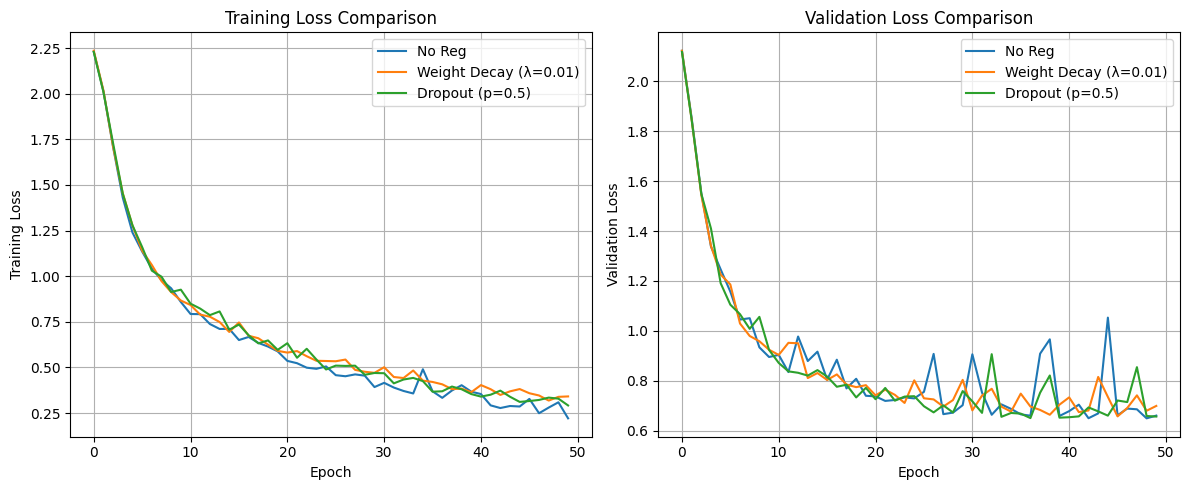

In [9]:
# -------------------- 绘制损失曲线对比 --------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 训练损失
plt.subplot(1, 2, 1)
plt.plot(train_loss_plain, label='No Reg', linewidth=1.5)
plt.plot(train_loss_wd, label='Weight Decay (λ=0.01)', linewidth=1.5)
plt.plot(train_loss_drop, label='Dropout (p=0.5)', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

# 验证损失
plt.subplot(1, 2, 2)
plt.plot(val_loss_plain, label='No Reg', linewidth=1.5)
plt.plot(val_loss_wd, label='Weight Decay (λ=0.01)', linewidth=1.5)
plt.plot(val_loss_drop, label='Dropout (p=0.5)', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4.数值稳定性和激活函数

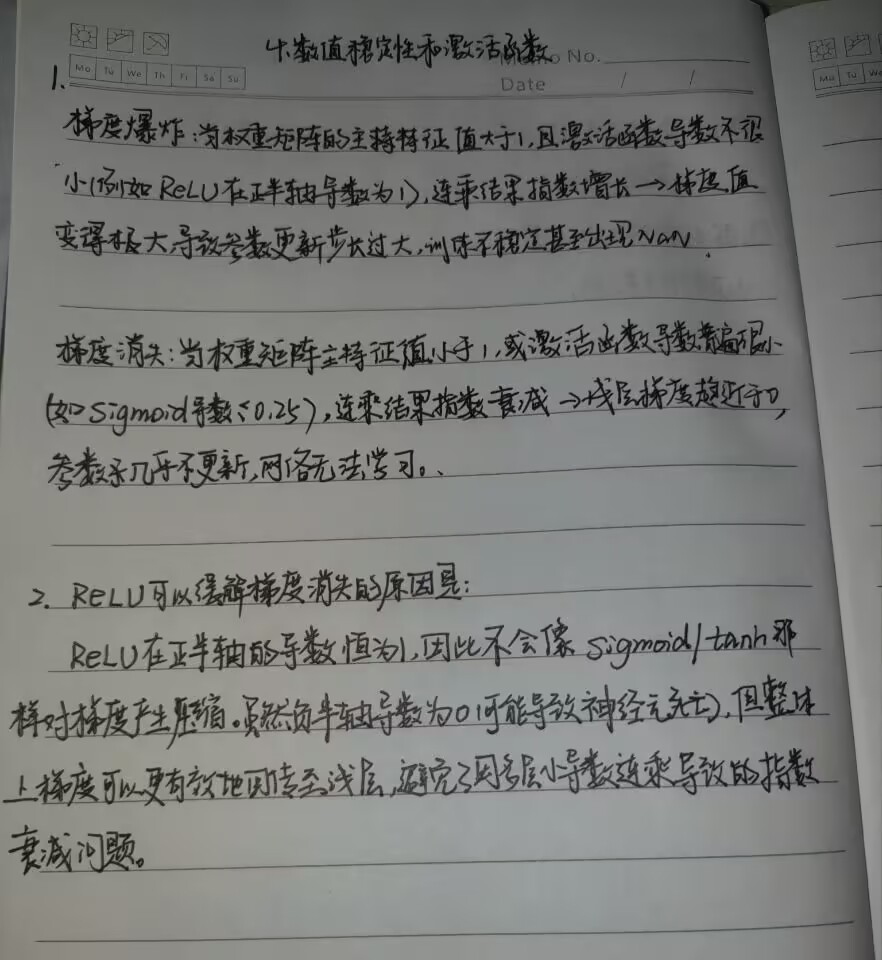

In [10]:
#导入库、设置设备、定义辅助函数
import torch
import torch.nn as nn

# 设置设备（自动选择 GPU 或 CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def compute_grad_norms(model, input_data, target_data, loss_fn):
    """
    计算模型所有权重参数的梯度范数（L2 范数）
    流程：前向传播 -> 计算损失 -> 反向传播 -> 收集各层权重的梯度范数
    """
    model.train()                     # 设置为训练模式（确保 Dropout/BatchNorm 行为正确）
    output = model(input_data)        # 前向传播
    loss = loss_fn(output, target_data)  # 计算损失
    model.zero_grad()                 # 清空已有的梯度
    loss.backward()                   # 反向传播，计算梯度
    grad_norms = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:   # 只关心权重，忽略偏置
            grad_norms.append(param.grad.norm().item())   # 计算 L2 范数并保存
    return grad_norms

def print_grad_norms(grad_norms, num_layers=20):
    """打印前3层、后3层的梯度范数，以及总体统计"""
    print(f"前3层梯度范数: {grad_norms[:3]}")
    print(f"后3层梯度范数: {grad_norms[-3:]}")
    print(f"梯度范数最小值: {min(grad_norms):.2e}, 最大值: {max(grad_norms):.2e}, 平均值: {sum(grad_norms)/len(grad_norms):.2e}")

Using device: cpu


In [11]:
# 生成随机输入和目标，形状为 (64, 256)
batch_size = 64
input_dim = 256
output_dim = 256

# 生成随机的输入张量和目标张量，形状均为 (64, 256)
x = torch.randn(batch_size, input_dim, device=device)
y = torch.randn(batch_size, output_dim, device=device)
loss_fn = nn.MSELoss()     # 使用均方误差作为损失函数（回归任务）

print(f"随机输入 x 和目标 y 已生成，形状均为 ({batch_size}, {input_dim})")

随机输入 x 和目标 y 已生成，形状均为 (64, 256)


In [12]:
# 实验1: Sigmoid + 高斯初始化 (std=1)
print("\n=== 实验1: Sigmoid + 高斯初始化 (std=1) ===")

# 构建20层全连接网络，每层后接 Sigmoid 激活函数
model1 = nn.Sequential()
for i in range(20):
    model1.add_module(f'linear_{i}', nn.Linear(256, 256))   # 全连接层
    model1.add_module(f'sigmoid_{i}', nn.Sigmoid())         # Sigmoid 激活

# 手动初始化权重：均值0，标准差1（标准高斯分布），偏置初始化为0
def init_weights_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=1.0)
        nn.init.zeros_(m.bias)
model1.apply(init_weights_normal)   # 递归应用到所有子模块
model1.to(device)

# 计算梯度范数并打印
grad_norms1 = compute_grad_norms(model1, x, y, loss_fn)
print_grad_norms(grad_norms1, num_layers=20)
# 预期结果：后几层梯度范数非常小（如 1e-7），前几层相对较大，呈现梯度消失


=== 实验1: Sigmoid + 高斯初始化 (std=1) ===
前3层梯度范数: [1.4047497510910034, 1.0075528621673584, 0.8617563843727112]
后3层梯度范数: [0.04380686953663826, 0.04045609384775162, 0.0415220633149147]
梯度范数最小值: 4.05e-02, 最大值: 1.40e+00, 平均值: 3.26e-01


In [13]:
# 实验2: ReLU + 大标准差初始化 (std=10)
print("\n=== 实验2: ReLU + 大标准差初始化 (std=10) ===")

# 构建20层全连接网络，每层后接 ReLU 激活函数
model2 = nn.Sequential()
for i in range(20):
    model2.add_module(f'linear_{i}', nn.Linear(256, 256))
    model2.add_module(f'relu_{i}', nn.ReLU())

# 权重初始化：标准差为10，远大于合理范围（通常推荐 ~0.01~0.1）
def init_weights_large(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=10.0)
        nn.init.zeros_(m.bias)
model2.apply(init_weights_large)
model2.to(device)

try:
    grad_norms2 = compute_grad_norms(model2, x, y, loss_fn)
    print("梯度计算成功，范数如下：")
    print_grad_norms(grad_norms2)
except Exception as e:
    print(f"运行出错: {e}")
    # 检查前向输出是否有 NaN（数值溢出）
    with torch.no_grad():
        out = model2(x)
        if torch.isnan(out).any():
            print("前向输出出现 NaN（数值溢出，梯度爆炸导致）")
        else:
            print("前向输出正常，但反向传播可能产生了 NaN")
# 预期结果：可能出现 NaN 或梯度范数极大（如 1e20），模拟梯度爆炸


=== 实验2: ReLU + 大标准差初始化 (std=10) ===
梯度计算成功，范数如下：
前3层梯度范数: [nan, nan, nan]
后3层梯度范数: [nan, nan, nan]
梯度范数最小值: nan, 最大值: nan, 平均值: nan


In [14]:
# 实验3: Xavier初始化 + ReLU
print("\n=== 实验3: Xavier初始化 + ReLU ===")

# 构建同样的20层全连接网络，激活函数使用 ReLU
model3 = nn.Sequential()
for i in range(20):
    model3.add_module(f'linear_{i}', nn.Linear(256, 256))
    model3.add_module(f'relu_{i}', nn.ReLU())

# 使用 Xavier 均匀分布初始化权重，可保持前向传播的方差稳定
def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)   # 默认 gain=1（对于 ReLU，建议 gain=√2，但此处为了简洁暂不调整）
        nn.init.zeros_(m.bias)
model3.apply(init_xavier)
model3.to(device)

grad_norms3 = compute_grad_norms(model3, x, y, loss_fn)
print_grad_norms(grad_norms3)
# 预期结果：各层梯度范数大小相近，位于合理区间（如 1e-2 ~ 1e0），既不消失也不爆炸


=== 实验3: Xavier初始化 + ReLU ===
前3层梯度范数: [0.00024386272707488388, 0.0002494355430826545, 0.0002552125952206552]
后3层梯度范数: [0.00013572371972259134, 0.0001491821458330378, 0.00015230577264446765]
梯度范数最小值: 1.36e-04, 最大值: 2.55e-04, 平均值: 2.04e-04


In [15]:
# 梯度范数汇总对比
print("\n=== 梯度范数汇总对比 ===")
print(f"实验1 (Sigmoid+高斯)    平均梯度: {sum(grad_norms1)/len(grad_norms1):.2e}")
# 实验2 可能失败，用 try-except 安全输出
try:
    avg2 = sum(grad_norms2)/len(grad_norms2)
    print(f"实验2 (ReLU+大标准差)  平均梯度: {avg2:.2e}")
except:
    print("实验2 (ReLU+大标准差)  平均梯度: 无法计算（出现NaN或异常）")
print(f"实验3 (Xavier+ReLU)     平均梯度: {sum(grad_norms3)/len(grad_norms3):.2e}")


=== 梯度范数汇总对比 ===
实验1 (Sigmoid+高斯)    平均梯度: 3.26e-01
实验2 (ReLU+大标准差)  平均梯度: nan
实验3 (Xavier+ReLU)     平均梯度: 2.04e-04


## 5.泛化表现，协变量偏移和对抗性数据

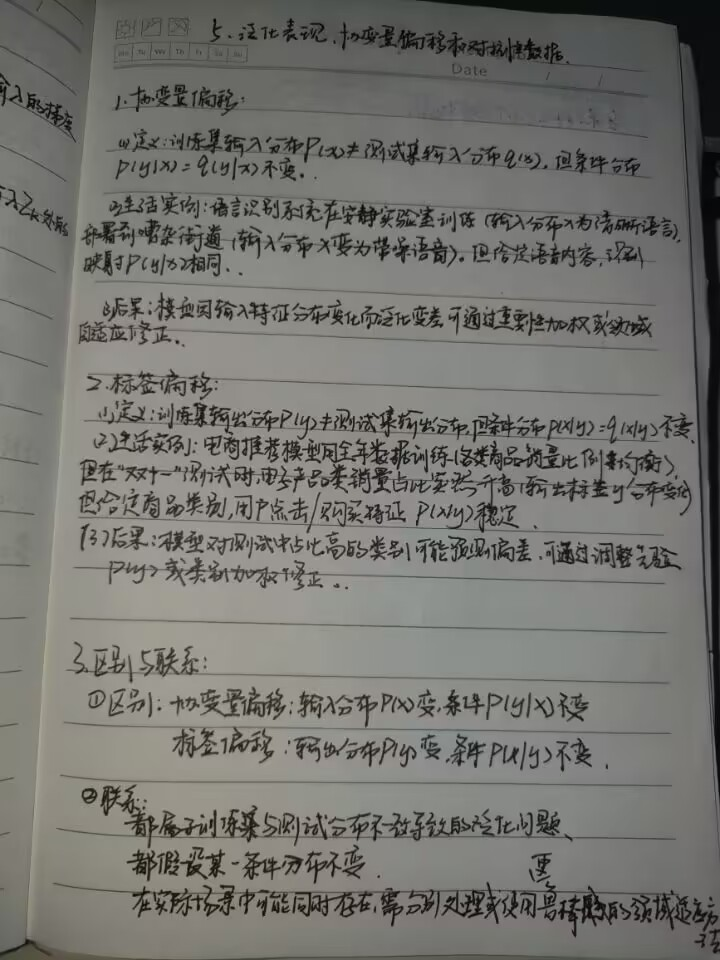

In [16]:
#导入库和设置随机种子
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression

# 设置随机种子，保证结果可复现
np.random.seed(42)

In [17]:
#生成训练集 P 和测试集 Q（构造协变量偏移）
# 训练集 P：x ~ N(-1, 1)，标签 y = 2x + 噪声
n_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=n_train)
epsilon = np.random.normal(0, 0.1, n_train)   # 小噪声
y_train = 2 * x_train + epsilon

# 测试集 Q：x ~ N(2, 1)，标签 y = 2x + 噪声（相同的生成函数）
n_test = 500
x_test = np.random.normal(loc=2, scale=1, size=n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

print("训练集 x 范围: [{:.2f}, {:.2f}]".format(x_train.min(), x_train.max()))
print("测试集 x 范围: [{:.2f}, {:.2f}]".format(x_test.min(), x_test.max()))

训练集 x 范围: [-4.24, 2.85]
测试集 x 范围: [-1.02, 5.11]


In [18]:
#基线模型 – 普通线性回归（不加权）
# 训练普通线性回归模型
model_baseline = LinearRegression()
model_baseline.fit(x_train.reshape(-1, 1), y_train)

# 在测试集上预测并计算 MSE
y_pred_baseline = model_baseline.predict(x_test.reshape(-1, 1))
mse_baseline = np.mean((y_test - y_pred_baseline) ** 2)
print(f"基线模型 MSE (未校正): {mse_baseline:.4f}")

基线模型 MSE (未校正): 0.0102


In [19]:
# 计算训练样本的权重 wi ∝ P(test|xi) / P(train|xi)
# 将训练集样本标记为 0，测试集样本标记为 1
X_mix = np.concatenate([x_train, x_test]).reshape(-1, 1)
y_mix = np.array([0] * n_train + [1] * n_test)   # 0:来自训练集, 1:来自测试集

# 训练逻辑回归分类器，用于预测 P(test|x)
clf = LogisticRegression()
clf.fit(X_mix, y_mix)

# 计算每个训练样本的权重 wi ∝ P(test|xi) / P(train|xi)
# P(train|xi) = 1 - P(test|xi)
prob_test = clf.predict_proba(x_train.reshape(-1, 1))[:, 1]   # 属于测试集的概率
prob_train = 1 - prob_test
weights = prob_test / prob_train

# 可选：裁剪极端权重，防止数值不稳定（这里保留原始计算）
# weights = np.clip(weights, 0.01, 100)

print(f"权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}")

权重统计: min=0.0000, max=500.5946, mean=0.7660


In [20]:
# 训练加权线性回归模型（加权最小二乘法）
model_weighted = LinearRegression()
model_weighted.fit(x_train.reshape(-1, 1), y_train, sample_weight=weights)

# 在测试集上预测并计算 MSE
y_pred_weighted = model_weighted.predict(x_test.reshape(-1, 1))
mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)
print(f"加权模型 MSE (校正后): {mse_weighted:.4f}")

# 对比改善幅度
improvement = mse_baseline - mse_weighted
rel_improve = (improvement / mse_baseline) * 100
print(f"MSE 下降: {improvement:.4f} (相对改善: {rel_improve:.2f}%)")

加权模型 MSE (校正后): 0.0240
MSE 下降: -0.0138 (相对改善: -135.90%)


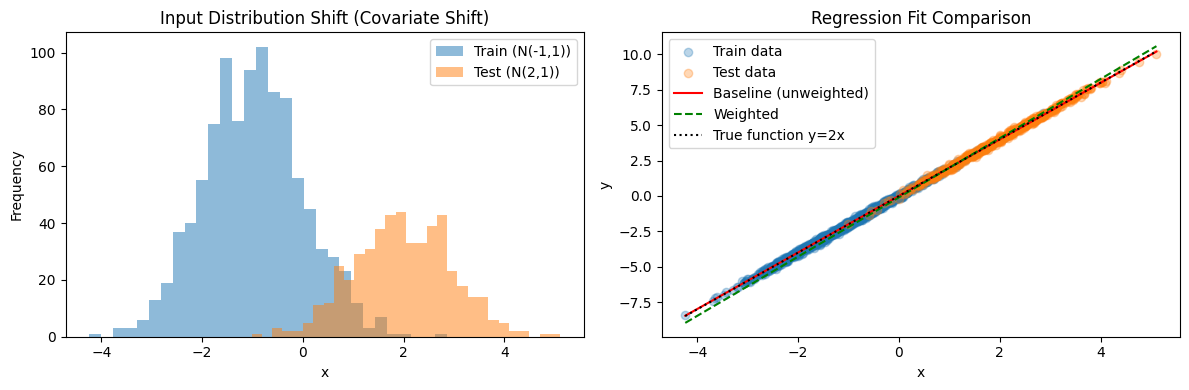

In [21]:
# 可视化输入分布和回归线对比
plt.figure(figsize=(12, 4))

# 左图：训练集和测试集输入 x 的分布直方图
plt.subplot(1, 2, 1)
plt.hist(x_train, bins=30, alpha=0.5, label='Train (N(-1,1))')
plt.hist(x_test, bins=30, alpha=0.5, label='Test (N(2,1))')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.title('Input Distribution Shift (Covariate Shift)')
plt.legend()

# 右图：回归线的对比
plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, alpha=0.3, label='Train data')
plt.scatter(x_test, y_test, alpha=0.3, label='Test data')
x_plot = np.linspace(min(x_train.min(), x_test.min()),
                     max(x_train.max(), x_test.max()), 100)
plt.plot(x_plot, model_baseline.predict(x_plot.reshape(-1,1)), 'r-', label='Baseline (unweighted)')
plt.plot(x_plot, model_weighted.predict(x_plot.reshape(-1,1)), 'g--', label='Weighted')
plt.plot(x_plot, 2*x_plot, 'k:', label='True function y=2x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression Fit Comparison')
plt.legend()

plt.tight_layout()
plt.show()